## M3 - Complete Implementation of Pattern Discovery in Smartphone Pricing and Hardware
#### CS - 4412
#### Victor Urey

The two discovery questions being analyzed are:
1. Which combinations of smartphone hardware features are most associated with high-end devices, and how consistently do these hardware groupings distinguish them from lower-end models?

2. What combinations of hardware features frequently appear together across smartphone models, and how do these groupings reflect common design patterns?

To investigate these questions this document will outline:
- Clustering Analysis using KMeans, DBSCAN, and Hierarchical techniques to find natural groupings of smartphone hardware into two distinct groupings.
- Association Rule Mining using Apriori and FP-Growth to discover frequent co-occurances of hardware specifications and how these hardware features contribute to common design patterns within devices.

In [265]:
%pip install pandas numpy matplotlib seaborn scikit-learn mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [266]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules

## 1. Dataset: Smartphone Specifications Dataset

This dataset contains nearly 1000 smartphone models and their hardware specifications including model name, screen size, camera resolution, included RAM, and price at release just to name a few.

In [267]:
phoneSpecs = pd.read_csv("smartphone specifications dataset.csv") # Import dataset
phoneSpecs[["price", "ram_gb", "storage_gb", "resolution", "battery_mah", "screen_size_in", "NFC", "rear_camera_max_mp", "rear_camera_count"]].head()

,price,ram_gb,storage_gb,resolution,battery_mah,screen_size_in,NFC,rear_camera_max_mp,rear_camera_count
0,54999,12,12,1440x3216,5000.0,6.70,True,50.0,3
1,19989,6,6,1080x2412,5000.0,6.59,False,64.0,3
2,16499,4,4,1080x2408,5000.0,6.60,False,50.0,3
3,14999,6,6,1080x2400,5000.0,6.55,False,50.0,3
4,24999,6,6,1080x2412,5000.0,6.70,False,108.0,3


In [268]:
phoneSpecs[["price", "ram_gb", "storage_gb", "resolution", "battery_mah", "screen_size_in", "NFC", "rear_camera_max_mp", "rear_camera_count"]].describe() # Show important columns

,price,ram_gb,storage_gb,battery_mah,screen_size_in,rear_camera_max_mp,rear_camera_count
count,968.000000,968.000000,968.000000,957.000000,967.000000,952.000000,968.000000
mean,32745.954545,7.641529,7.641529,4819.935214,6.535998,50.737395,2.268595
std,39707.710721,23.123619,23.123619,1012.724563,0.381498,33.209502,0.905096
min,2999.000000,1.000000,1.000000,1500.000000,2.400000,2.000000,0.000000
25%,12999.000000,4.000000,4.000000,4500.000000,6.500000,48.000000,1.000000
50%,19999.000000,6.000000,6.000000,5000.000000,6.580000,50.000000,3.000000
75%,35992.250000,8.000000,8.000000,5000.000000,6.670000,64.000000,3.000000
max,650000.000000,512.000000,512.000000,22000.000000,8.030000,200.000000,4.000000


Before analyzing this dataset there are a few values that must be cleaned:
- Inconsistent phone model naming
- Possible duplicates (or variations of the same model)
- Model name and Brand in the same column, should be split into 2 columns
- Pricing values are represented without decimals (1000 -> 10.00)

In [269]:
phoneSpecs.isnull().sum() # Overview of null columns

model                      0
price                      0
rating                     0
os                        26
sim_type                   0
network_type               0
VoLTE                      0
NFC                        0
ir_blaster                 0
chipset                    0
core_type                  6
clock_ghz                 41
ram_gb                     0
storage_gb                 0
battery_mah               11
fast_charge_w            204
screen_size_in             1
resolution                 1
refresh_rate_hz          360
display_type              85
rear_camera_mp_list        0
rear_camera_count          0
rear_camera_max_mp        16
front_camera_mp           25
memory_card_supported      0
memory_card_type         127
memory_card_max_gb       468
dtype: int64

In [270]:
phoneSpecs = phoneSpecs.dropna(subset=['model', 'price', 'resolution', 'battery_mah', 'screen_size_in', 'rear_camera_max_mp']) # Removes rows with NULL values in these important columns

This dataset includes both the brand and the model information in the same cell (e.g. iPhone 14 Pro-Max). Solving this requires that we:
1. Split the brand and model names (iPhone, 14 Pro-Max)
2. Clean special characters (Pro-Max -> Pro Max)


In [271]:
# Split brand and model names into two columns
def splitBrandModel(text): # Standardize names into lowercase
    text = str(text).lower().strip()
    piece = text.split(" ", 1)
    return piece[0], piece[1]

# Create new columns (brand & model)
phoneSpecs["brand"], phoneSpecs["model"] = zip(*phoneSpecs["model"].apply(splitBrandModel)) 

# Moves new brand column to column 0
column = phoneSpecs.pop("brand")
phoneSpecs.insert(0, "brand", column)

# Remove duplicate prices per model, keep median price
median = phoneSpecs.groupby(['brand', 'model'])['price'].median().reset_index()
median = median.rename(columns={'price': 'median price'})
phoneSpecs = phoneSpecs.merge(median, on=['brand', 'model'])
phoneSpecs = phoneSpecs[phoneSpecs['price'] == phoneSpecs['median price']]

phoneSpecs = phoneSpecs.drop(columns='median price')
phoneSpecs = phoneSpecs.reset_index(drop=True)

# Price formatting
phoneSpecs["newPrice"] = phoneSpecs["price"] // 100 # Remove cents
column = phoneSpecs.pop("price")
phoneSpecs.rename(columns={"newPrice": "price"}, inplace=True) # Rename new column back to price
column = phoneSpecs.pop("price")
phoneSpecs.insert(0, "price", column) # Move price column to front

phoneSpecs[["brand", "model", "price", "ram_gb", "battery_mah", "screen_size_in", "rear_camera_max_mp"]].head()

,brand,model,price,ram_gb,battery_mah,screen_size_in,rear_camera_max_mp
0,oneplus,11 5g,549,12,5000.0,6.70,50.0
1,motorola,moto g62 5g,149,6,5000.0,6.55,50.0
2,xiaomi,redmi note 12 pro plus,299,8,4980.0,6.67,200.0
3,oneplus,nord 2t 5g,289,8,4500.0,6.43,50.0
4,oppo,a78,189,8,5000.0,6.56,50.0


## 2. Exploratory Data Analysis (EDA)
#### 2.1 Univariate Analysis

In [272]:
phoneSpecs[["ram_gb", "storage_gb", "resolution", "battery_mah", "screen_size_in", "NFC", "rear_camera_max_mp", "rear_camera_count"]].describe()

,ram_gb,storage_gb,battery_mah,screen_size_in,rear_camera_max_mp,rear_camera_count
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,7.590139,7.590139,4802.277350,6.542080,52.036980,2.320493
std,20.022864,20.022864,1137.936043,0.372696,34.279469,0.858273
min,1.000000,1.000000,1821.000000,2.400000,2.000000,1.000000
25%,4.000000,4.000000,4500.000000,6.500000,48.000000,2.000000
50%,8.000000,8.000000,5000.000000,6.580000,50.000000,3.000000
75%,8.000000,8.000000,5000.000000,6.700000,64.000000,3.000000
max,512.000000,512.000000,22000.000000,8.030000,200.000000,4.000000


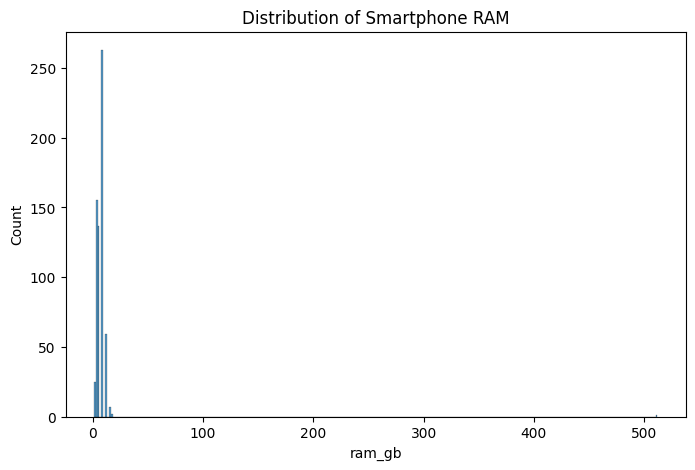

In [273]:
plt.figure(figsize=(8,5))
sns.histplot(phoneSpecs['ram_gb'], bins=300) # 300 was chosen for visualization purposes
plt.title("Distribution of Smartphone RAM")
plt.show()

After reviewing the RAM documentation for the two right-most outliers in this set, these devices do have 512GB of RAM on board and should be kept in the dataset as valid data points.

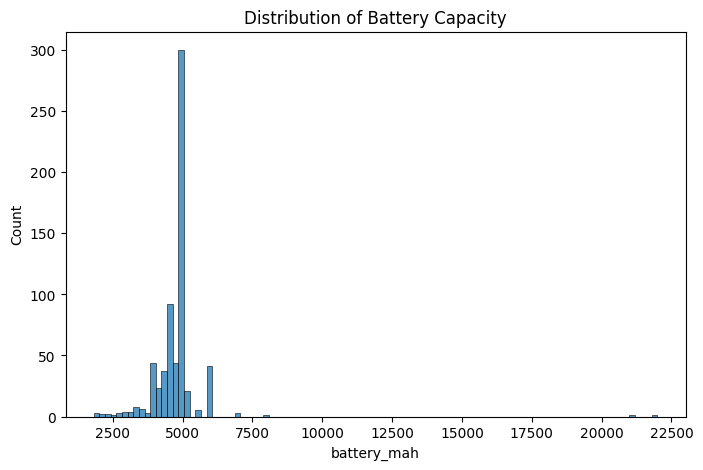

In [274]:
plt.figure(figsize=(8,5))
sns.histplot(phoneSpecs['battery_mah'], bins=100) # 100 was chosen to show spread
plt.title("Distribution of Battery Capacity")
plt.show()

Battery capacity shows a good spread of ranges, slightly right skewed, and has a few outliers above 20,000 mAh. It seems that most devices sit between the 2500 and 6000 range, with a few devices pushing past that. 

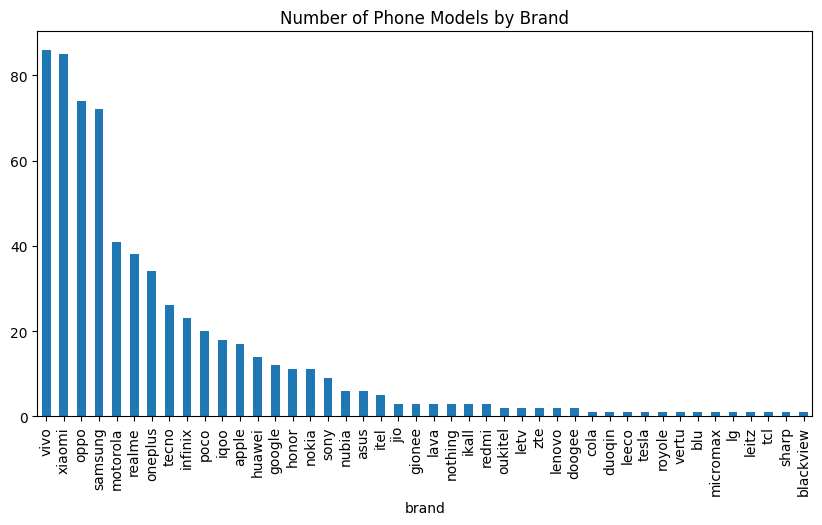

In [275]:
phoneSpecs['brand'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Number of Phone Models by Brand")
plt.show()

This is a visualization of the dominating brands in this dataset. Vivo, Xiaomi, Oppo, and Samsung are the top four most common devices on this list. This dataset will provide meaningful data across all brands but it is important to remember which brands may be skewing data in one direction or another.

#### 2.1 Bivariate and Multivariate Analysis

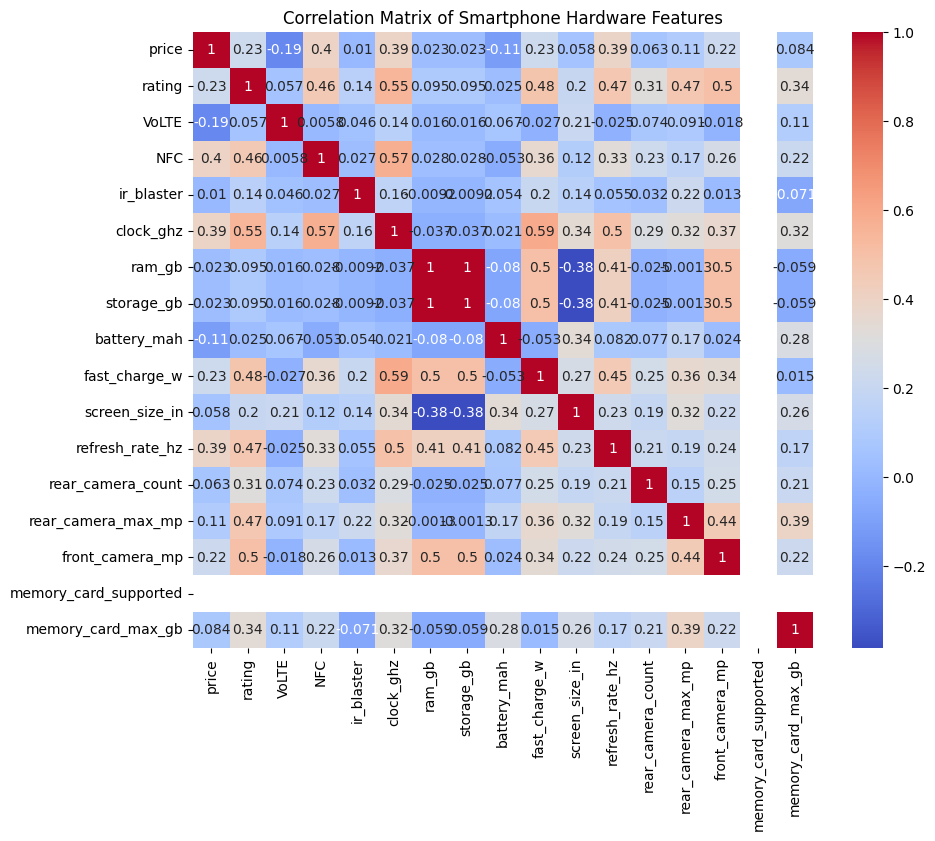

In [276]:
plt.figure(figsize=(10,8))
sns.heatmap(phoneSpecs.corr(numeric_only=True), annot=True, cmap='coolwarm') # Setup for heat map
plt.title("Correlation Matrix of Smartphone Hardware Features")
plt.show()

The correlation matrix of features provides a good overview of how one variable may be affecting another. 
- Surprisingly, price has relatively weak correlations with most other features. This means that pricing for high-end devices is comprised of combinations of RAM, Camera Resolution, Battery Capacity, and Screen Size, not just one feature alone.
- The strong correlation between ram and storage is to be expected from hardware pairings. Using a log transformation of ram and storage values should help ensure that these values are being represented fairly.

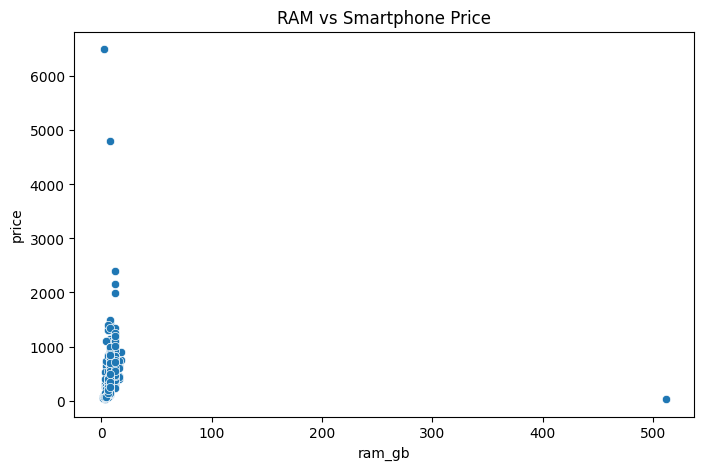

In [277]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=phoneSpecs, x='ram_gb', y='price')
plt.title("RAM vs Smartphone Price")
plt.show()

Among most phone models, it seems that RAM by itself only slightly affects the pricing of smartphones. This, given the data from the correlation matrix, leads me to believe that individual hardware features do not produce natural groupings of smartphone pricing but combinations of these features may.

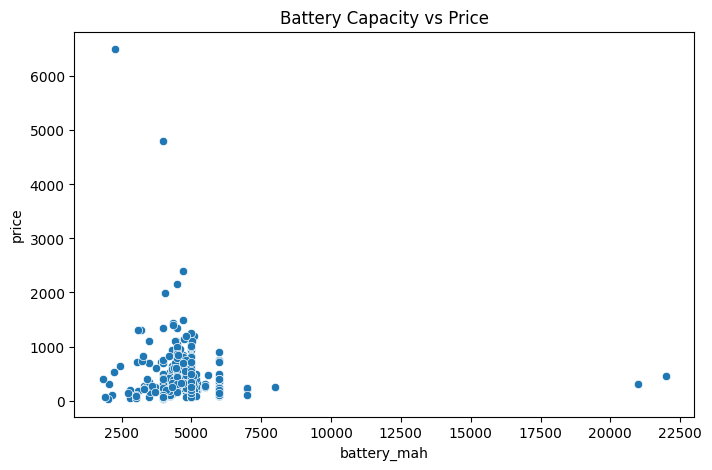

In [278]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=phoneSpecs, x='battery_mah', y='price')
plt.title("Battery Capacity vs Price")
plt.show()

This graph demonstrates a slightly wider spread of values between battery and pricing. This may be useful for analyzing devices with large batteries since they may be naturally grouped into their own tier of devices later on.

#### 2.3 Connecting EDA to Discovery Questions

##### DQ1: Which combinations of smartphone hardware features are most associated with high-end devices, and how consistently do these hardware groupings distinguish them from lower-end models?

The EDA revealed that no single feature among RAM, storage, battery or camera is responsible for dominating the high-end pricing or classification of devices. Instead I found that high-end devices contain a combination of featuers that may be revealed in clustering and association rule methods.

##### DQ2: What combinations of hardware features frequently appear together across smartphone models, and how do these groupings reflect common design patterns?

The EDA shows that there are some consistent harware pairings across the dataset. RAM and storage values are strongly linked whereas battery and screen size have a moderately large spread. The majority of devices hover around mid-level values for camera specifications and battery capacity. Again, this emphasises that there are multiple features at play and not one single variable that is skewing the distribution of smartphones across natural groups.

## 3. Data Preprocessing
#### 3.1 Missing Values
The smartphone specifications dataset contains some missing values across important categories like battery capacity, ram in gb, or camera specifics. Instead of removing all the entries in the dataset that were missing a value, I only removed entries in the table that were missing any of these select variables:
- Model
- Price
- OS
- Resolution
- Battery mAh
- Screen Size in Inches
- Rear Camera Max MegaPixels



In [279]:
phoneSpecs = phoneSpecs.dropna(subset=['model', 'price', 'os', 'resolution', 'battery_mah', 'screen_size_in', 'rear_camera_max_mp']) # Removes rows with NULL values in these important columns

Removing ALL values with missing values would be detrimental to the pattern analysis because it would remove nearly half of the entire table. For this reason I decided to focus on key features that better reflect the most popoular hardware specifications we see in phones today. 

##### 3.2 Outliers
There were a few apparent outliers in price, RAM, and in battery life. The EDA discovered these outliers and plotted below are the outliers for price in the dataset:

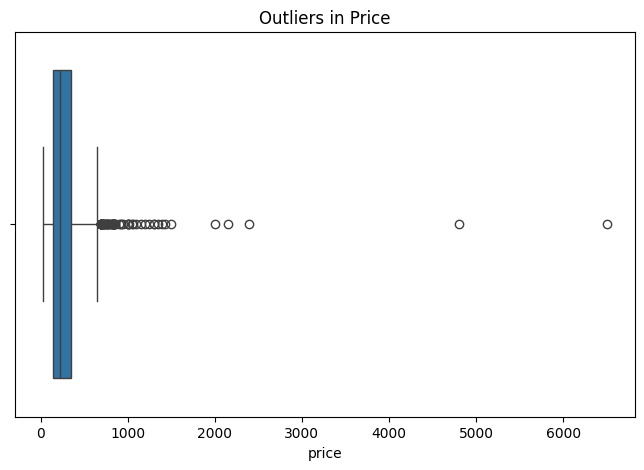

In [280]:
plt.figure(figsize=(8,5))
sns.boxplot(x=phoneSpecs['price'])
plt.title("Outliers in Price")
plt.show()

After double checking the two right-most outliers online, I found that these extreme values represent actual high-end devices rather than data errors. I decided to keep these devices in the dataset so that the entire range of devices was considered.

## 4. First Mining Technique: Clustering
#### 4.1 Clustering
Clustering is supportive of both discovery questions because it helps discover natural groupings based on cobinations of hardware specifications. Clusters may show differences between hardware design and how these hardware groupings can be indicative of the types of models they are found in.

#### 4.2 Clustering Implementation
For the clustering I used these variables:
- RAM in GB
- Storage in GB
- Battery Capacity in mAh
- Rear Camera Max MegaPixels

#### 4.3 Scaling
Because variables like RAM and storage grew exponentially it was important to provide a form of log transformations before clustering. I log transformed RAM, storage, battery, and rear camera since there is a wide spread in all of these categories.

In [ ]:
# Used in clustering
phoneSpecs['log_ram'] = np.log1p(phoneSpecs['ram_gb'])
phoneSpecs['log_storage'] = np.log1p(phoneSpecs['storage_gb'])
phoneSpecs['log_battery'] = np.log1p(phoneSpecs['battery_mah'])
phoneSpecs['log_rear_camera'] = np.log1p(phoneSpecs['rear_camera_max_mp'])


In [282]:
phoneSpecs[["log_ram", "log_storage", "log_battery", "log_rear_camera"]].describe() # Show important columns

,log_ram,log_storage,log_battery,log_rear_camera
count,640.000000,640.000000,640.000000,640.000000
mean,1.989835,1.989835,8.460258,3.736315
std,0.412571,0.412571,0.178441,0.752923
min,0.693147,0.693147,7.507690,1.098612
25%,1.609438,1.609438,8.412055,3.891820
50%,2.197225,2.197225,8.517393,3.931826
75%,2.197225,2.197225,8.517393,4.174387
max,6.240276,6.240276,9.998843,5.303305


In [283]:
from sklearn.preprocessing import StandardScaler

# Holds updated values for clustering
numericCol = ["log_ram", "log_storage", "log_battery", "log_rear_camera"]
features = phoneSpecs[numericCol]


scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#### 4.4 KMeans Clustering

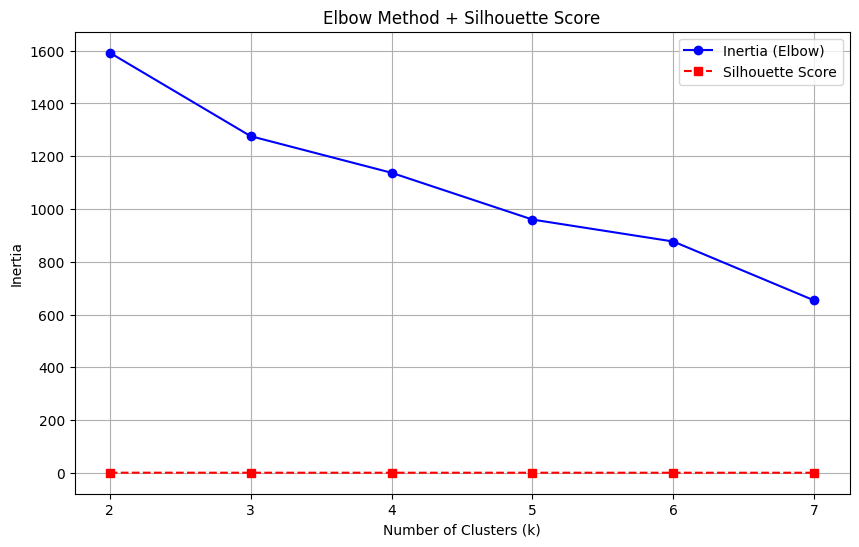

          log_ram  log_storage  log_battery  log_rear_camera
cluster                                                     
0        2.122479     2.122479     8.487757         4.056414
1        1.502831     1.502831     8.359292         2.561061
log_ram            0.170214
log_storage        0.170214
log_battery        0.031841
log_rear_camera    0.566893
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 8) # Find cluster between 2 and 7
inertia = []
silhouetteScore = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)

    inertia.append(kmeans.inertia_)

    silhouetteScore.append(silhouette_score(scaled_features, labels))

best_k = k_values[silhouetteScore.index(max(silhouetteScore))] # Find best k value for clustering

kmeans = KMeans(n_clusters=best_k, random_state=42)
phoneSpecs['cluster'] = kmeans.fit_predict(scaled_features) # Run KMeans with k

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, 'o-', color='blue', label='Inertia (Elbow)')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method + Silhouette Score")
plt.grid(True)

# Overlay sillouette scores on plot
plt.plot(k_values, silhouetteScore, 's--', color='red', label='Silhouette Score')

plt.legend()
plt.show()

# Cluster Data values
cluster_summary = phoneSpecs.groupby('cluster')[features.columns].mean()
print(cluster_summary)


print(phoneSpecs[numericCol].var())

##### Interpretation of KMeans Clustering
KMeans clustering has showed a k value of 2, producing two loosely defined clusters. Cluster 0 represents phones with higher RAM, higher storage, and better battery while Cluster 1 showes slightly lower RAM/storage and weaker cameras. These variables did not show significant variance and all silhouette scores were essentially 0. This is a poor separation of clusters and shows how phones are not naturally separated into rigid groups by hardware specifications alone. This method produced data that was not very valuable to the discussion questions provided above.

#### 4.5 DBSCAN Clustering
Secondly I applied the DBSCAN technique of clustering to see what results that would provide on these 4 main variables. I implemented a k-distance plot for nearest neighbors to pick a proper value for eps.

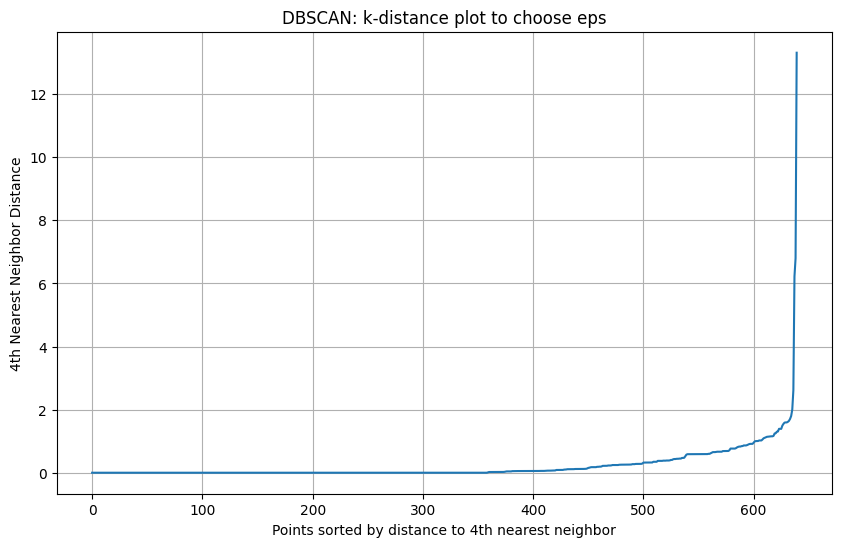

In [285]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_features)
distances, indices = neighbors_fit.kneighbors(scaled_features)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10,6))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance to 4th nearest neighbor")
plt.ylabel("4th Nearest Neighbor Distance")
plt.title("DBSCAN: k-distance plot to choose eps")
plt.grid(True)
plt.show()

The "elbow" of this plot falls around a y value of 1.0 - 1.1. This is the value I used for eps in the DBSCAN implementation below.

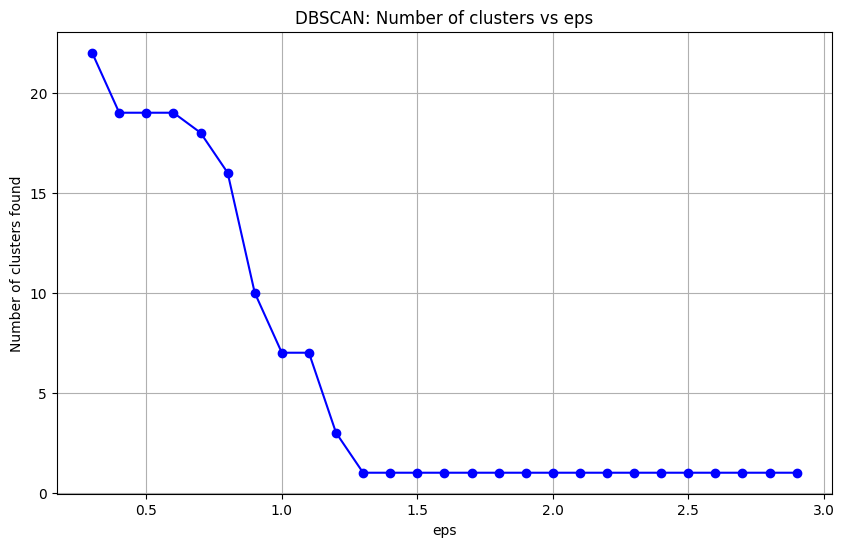

eps=0.30 -> 22 clusters
eps=0.40 -> 19 clusters
eps=0.50 -> 19 clusters
eps=0.60 -> 19 clusters
eps=0.70 -> 18 clusters
eps=0.80 -> 16 clusters
eps=0.90 -> 10 clusters
eps=1.00 -> 7 clusters
eps=1.10 -> 7 clusters
eps=1.20 -> 3 clusters
eps=1.30 -> 1 clusters
eps=1.40 -> 1 clusters
eps=1.50 -> 1 clusters
eps=1.60 -> 1 clusters
eps=1.70 -> 1 clusters
eps=1.80 -> 1 clusters
eps=1.90 -> 1 clusters
eps=2.00 -> 1 clusters
eps=2.10 -> 1 clusters
eps=2.20 -> 1 clusters
eps=2.30 -> 1 clusters
eps=2.40 -> 1 clusters
eps=2.50 -> 1 clusters
eps=2.60 -> 1 clusters
eps=2.70 -> 1 clusters
eps=2.80 -> 1 clusters
eps=2.90 -> 1 clusters


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Range of eps values to try
eps_values = np.arange(0.3, 3.0, 0.1)
cluster_counts = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(scaled_features)
    
    # Number of clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    cluster_counts.append(n_clusters)

plt.figure(figsize=(10,6))
plt.plot(eps_values, cluster_counts, 'o-', color='blue')
plt.xlabel("eps")
plt.ylabel("Number of clusters found")
plt.title("DBSCAN: Number of clusters vs eps")
plt.grid(True)
plt.show()

# Display print for clusters vs eps
for e, c in zip(eps_values, cluster_counts):
    print(f"eps={e:.2f} -> {c} clusters")

This plot shows how DBSCAN divides the dataset into clusters based on the eps values used. Small values (0.3-0.7) created more than 20 clusters and each cluster did not have meaningful data. Medium values (0.9-1.1) showed a more reasonable number of clusters but still over-partitioned the data. Lastly, large values (1.2 or greater) only resulted in a single cluster, suggesting that the variances in data was simply too small to produce distinct clustering.

In [287]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(scaled_features)

In [ ]:
import numpy as np

# Number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

phoneSpecs['dbscan_cluster'] = labels

Number of clusters found: 3
Number of noise points: 15


In [289]:
# Only for points assigned to clusters
clustered_points = phoneSpecs[phoneSpecs['dbscan_cluster'] != -1]

cluster_summary = clustered_points.groupby('dbscan_cluster')[numericCol].mean()
print(cluster_summary)

                 log_ram  log_storage  log_battery  log_rear_camera
dbscan_cluster                                                     
0               2.612036     2.612036     8.491887         4.189843
1               1.931396     1.931396     8.458438         3.744168
2               2.564949     2.564949     8.436009         2.512477


##### Interpretation of DBSCAN
Cluster formation using different values of eps were all over the place. Either small values produces 20+ clusters or large values produced a single, uniform cluster. Only in moderate values of eps did the clustering produce reasonable groupings that showed outliers and noise points that were useful to our dataset. 

#### 4.6 Hierarchal Clustering

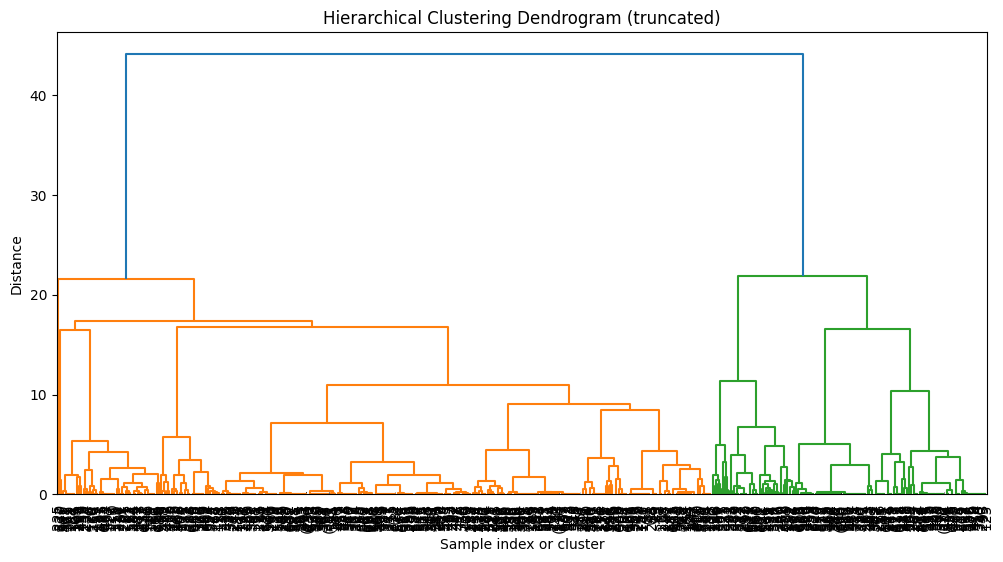

             log_ram  log_storage  log_battery  log_rear_camera
hc_cluster                                                     
0           2.192065     2.192065     8.479293         4.027340
1           1.551871     1.551871     8.091789         2.556682
2           1.497010     1.497010     8.524486         3.212803
Hierarchical cluster counts: [  0 450  48 142]


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Wards method for z
Z = linkage(scaled_features, method='ward')

# Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode='level',  
    p=20,                   
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Sample index or cluster')
plt.ylabel('Distance')
plt.show()

# 3 clusters to compare to kmeans
num_clusters = 3
hc_labels = fcluster(Z, num_clusters, criterion='maxclust')

phoneSpecs['hc_cluster'] = hc_labels - 1  # Starts at 0

hc_summary = phoneSpecs.groupby('hc_cluster')[numericCol].mean()
print(hc_summary)

# Display of cluster sizing
import numpy as np
print("Hierarchical cluster counts:", np.bincount(hc_labels))

##### Interpretation of Hierarchal
This method provided a more discrete view of these three smartphone groups. It showed how Cluster 0 has most of the devices, making this the most likely candidate for a mid to high-range devices on account of its large values in each category. Cluster 1 may be budget or mid-range devices that suffer in battery and camera specifications. And lastly Cluster 2 shows 142 devices that are solid all around and may have more emphasis on camera quality or battery life.

##### Comparing all 3 Clustering Methods
The KMeans tehnique of clustering forced clusters to be almost equal in size. This resulted in the dataset being split into 2 halves, mostly on account of large variances within battery or RAM. This correlation was rather weak however and I don't feel confident that this form of clustering provided much value beyond emphasizing the large variances in data values, even after log transformations.

DBSCAN performed rather efficiently. It was useful for detecting outliers and noise points and provided natural groupings of hardware within the dataset. The eps was a difficult value to dial in and provided drastically different results based on the values being used. For most values of eps there was not enough variance to group the dataset into more than a single, unified cluster. However, DBSCAN did provide meaningul data when used with a eps of 1.2, showing that camera quality may be a major separator among all three clusters.

Lastly, Hierarchical clustering provided the most interesting natural groupings of the three methods. It was able to capture the distance between clusters, a stronger point of data for a dataset with values so similar. It wasn't heavily affected by something like "k" in KMeans or eps in DBSCAN so it was able to group the data into clusters that made sense, even if they were uneven. This form of clustering confirmed that most devices are similar and have very little variation, but was useful because it highlighed smaller subgroups within the single, larger cluster. This seemed to fit the data better and provided at least some value to the clustering when compared to the other two methods.

#### 4.7 Connection to Discovery Questions
##### DQ1: Which combinations of smartphone hardware features are most associated with high-end devices, and how consistently do these hardware groupings distinguish them from lower-end models?
KMeans and DBSCAN clustering provided somewhat weak results when it came to discovering natural groupings based on hardware specifications. Silhouette scores in KMeans were all essentially 0 and there was a weak separation of clusters even when reducing the variables being used. DBSCAN suffered in the same regard where eps values either produces too many small clusters or one large cluster than provided nothing of use. Hierarchical clustering was the only one to provide clusters that separated devices into 3 main groups based on RAM, storage, battery, and camera specifications.

##### DQ2: What combinations of hardware features frequently appear together across smartphone models, and how do these groupings reflect common design patterns?
Clusters are existant but not clear-cut. KMeans hardly shows any form of clustering since the elbow method is producing points that are nearly linear. DBSCAN was highly inconsistent and did not produce meaningful patterns to this discovery question. Hierarchical clustering separated devices into 3 main groups:
- Premium Devices: High RAM, high storage, better battery, better camera
- Mid-level Devices: Moderate RAM, moderate storage, good battery, good camera
- Low-End Devices: Lowest RAM, low storage, moderate battery, and moderate camera

## 5. Second Mining Technique: Association Rules (Apriori and FP-Growth)
#### 5.1 Association Rules
Association Rules are useful for discovery because they can reveal the difference between high, mid, and low-end devices and the hardware components that make these devices up. It aims to define which combinations of hardware specs are common and how these combinations reflect design patterns across brands.

#### 5.2 Apriori
For Apriori I'm going to use the following variables divided into 3 categories each:
- RAM (low, mid, high)
- Storage (low, mid, high)
- Battery (low, mid, high)
- Camera (low, mid, high)
- Screen Size (low, mid, high)

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder

# Creation of tiers, high, mid, low
phoneSpecs['ram_tier'] = pd.cut(phoneSpecs['ram_gb'], bins=[0, 4, 8, np.inf], labels=['ram_low','ram_mid','ram_high'])
phoneSpecs['storage_tier'] = pd.cut(phoneSpecs['storage_gb'], bins=[0, 64, 128, np.inf], labels=['storage_low','storage_mid','storage_high'])
phoneSpecs['battery_tier'] = pd.cut(phoneSpecs['battery_mah'], bins=[0, 4000, 5000, np.inf], labels=['battery_low','battery_mid','battery_high'])
phoneSpecs['rear_camera_mp_tier'] = pd.cut(phoneSpecs['rear_camera_max_mp'], bins=[0, 12, 48, np.inf], labels=['rear_camera_low','rear_camera_mid','rear_camera_high'])
phoneSpecs['screen_tier'] = pd.cut(phoneSpecs['screen_size_in'], bins=[0, 6.5, 6.8, np.inf], labels=['screen_small','screen_medium','screen_large'])

# Association rules features list
aprioriFeatures = ['ram_tier', 'storage_tier', 'battery_tier', 'rear_camera_mp_tier', 'screen_tier']
transactions = phoneSpecs[aprioriFeatures].apply(lambda x: list(x), axis=1).tolist()

# Matrix for transaction
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Frequent itemsets
frequent_itemsets = apriori(df_apriori, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

#Sort by lift and confidence
rules_sorted = rules.sort_values(['lift', 'confidence'], ascending=False)

rules_display = rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))

# Display top 20 in table
print(rules_display.head(20))

                                     antecedents  \
350                     storage_low, battery_low   
347                        screen_small, ram_low   
93                                   battery_low   
355                                  battery_low   
88                         screen_small, ram_low   
342           screen_small, ram_low, storage_low   
407               screen_medium, rear_camera_mid   
668  screen_medium, rear_camera_mid, storage_low   
676               screen_medium, rear_camera_mid   
410                         ram_low, battery_mid   
673            ram_low, storage_low, battery_mid   
681                         ram_low, battery_mid   
346                    screen_small, storage_low   
351                         ram_low, battery_low   
90                          ram_low, battery_low   
345            ram_low, storage_low, battery_low   
91                                  screen_small   
352                                 screen_small   
11          

C:\Users\victo\AppData\Local\Temp\ipykernel_11928\118601050.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
C:\Users\victo\AppData\Local\Temp\ipykernel_11928\118601050.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))


##### Co-occurrence Matrix

In [293]:
import pandas as pd
import numpy as np

# Get all unique items from rules
items = sorted(list(set(
    item for sublist in rules['antecedents'].tolist() + rules['consequents'].tolist()
    for item in sublist
)))

# Initialize matrix
lift_matrix = pd.DataFrame(np.nan, index=items, columns=items)

# Fill matrix using rules
for _, row in rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            lift_matrix.loc[a, c] = row['lift']

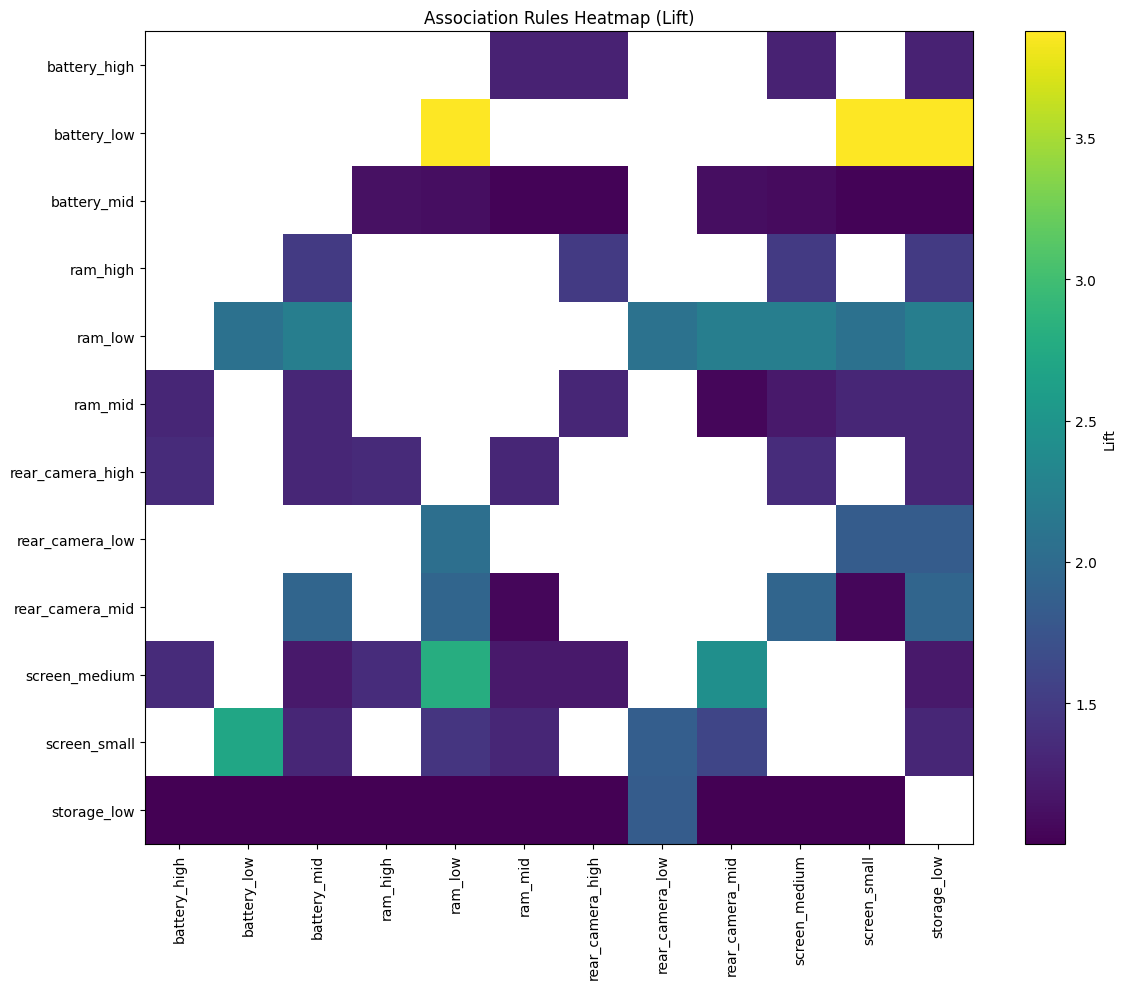

In [294]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.imshow(lift_matrix, aspect='auto')

plt.xticks(range(len(lift_matrix.columns)), lift_matrix.columns, rotation=90)
plt.yticks(range(len(lift_matrix.index)), lift_matrix.index)

plt.title("Association Rules Heatmap (Lift)")
plt.colorbar(label='Lift')

plt.tight_layout()
plt.show()

This heatmap shows strong correlations between hardware components in low-end and mid-level devices. 

Low-end devices:
- Low-end devices tend to bundle low battery with small screens and low ram and storage. This is shown by strong lift (> 3.5) among battery_low and storage_low, battery_low and screen_small, and ram_low and storage_low.

Mid-level devices:
- Mid level devices show that hardware components are mixed in value instead of maximizing one. There is very strong lift (~ 3.0) across screen_medium and rear_camera_mid, and ram_mid and battery_mid variables.

High-end devices:
- These devices didn't show hardware components to be as strongly linked. This could be representative of different brand design patterns or how high-end features are more selective rather than appear together. This makes high-end devices hard to cluster into a distinct category since not all premium components are used in every device.


#### 5.2 FP-Growth
FP-Growth is implemented using the same input as Apriori above.

In [295]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

frequent_itemsets_fp = fpgrowth(df_apriori, min_support=0.1, use_colnames=True)

rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=0.6)

# Sort for readability
rules_fp = rules_fp.sort_values(by='lift', ascending=False)

# Display
rules_fp_display = rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()

rules_fp_display['antecedents'] = rules_fp_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_fp_display['consequents'] = rules_fp_display['consequents'].apply(lambda x: ', '.join(list(x)))

display(rules_fp_display.head(20))

,antecedents,consequents,support,confidence,lift
181,battery_low,screen_small,0.106250,0.918919,2.613814
183,"storage_low, battery_low",screen_small,0.104688,0.917808,2.610654
184,battery_low,"screen_small, storage_low",0.104688,0.905405,2.586873
166,rear_camera_mid,ram_low,0.159375,0.603550,2.145957
170,"rear_camera_mid, storage_low",ram_low,0.159375,0.603550,2.145957
172,rear_camera_mid,"ram_low, storage_low",0.159375,0.603550,2.145957
82,"screen_medium, storage_low, ram_mid","rear_camera_high, battery_mid",0.295312,0.732558,1.378933
75,"screen_medium, ram_mid","rear_camera_high, battery_mid",0.295312,0.732558,1.378933
89,"screen_medium, ram_mid","rear_camera_high, storage_low, battery_mid",0.295312,0.732558,1.378933
72,"screen_medium, ram_mid, battery_mid",rear_camera_high,0.295312,0.883178,1.371926


##### FP-Growth Results
Results from FP-Growth are very similar to Apriori. The two strongest low-end patterns are:
- battery_low and screen_small
- (storage low + battery_low) and screen_small
Devices with small batteries often have small screens and devices with small storage and small battery consistently involve devices with smaller screens. 

Interestingly, the mid tier category uncovered a new pattern between rear_camera_mid and ram_low. It showed a high lift of 2.14 and a confidence of 0.6, representing some mid-tier phones that prioritize better cameras over increasing ram. Other mid-tier results are:
- (screen_medium + ram_mid) amd (rear_camera_high + battery_mid)
This suggests that mid-tier devices tend to stick with medium size screens, but budget on storage and ram. 

As for high-end devices, there were not substatial patterns found that link high-end devices to a common combination of high-end hardware.




## 6. Findings and Interpretation
#### Relation to Discovery Question 1
Of the three clustering methods, the hierarchical technique was the most useful in revealing tiers of devices based on features like RAM, battery, and camera quality. This separated the dataset into 3 main clusters, one for low RAM and smaller batteries, and other had greater RAM and stronger camera qualities. However, none of the forms of clustering were not clear-cut and a lot of the clustering techniques produced a single, uninformative cluster after processing the data. On the other hand, association rule mining provided much better results by revealing the combinations of hardware that contributed to these patterns in smartphone design. It showed how mid-range devices sometimes upgrade to better cameras without improving on RAM or storage specifications. 

#### Relation to Discovery Question 2
Association rule mining through Apriori and FP-Growth were especially useful in revealing reccuring combinations of hardware features in smartphone design patterns. The strongest and most consistent combinations were in low-end devices where the highest confidence and lift values were found. These devices often had low storage, low RAM, and very rarely upgrades to medium sized screens. Most interestingly, the mid-tier results showed that there is a common pattern of upgrading camera specifications but leaving RAM and storage constant. These compromises in phone hardware are what differentiates brands and its cool to see those results take place before the high-end devices. 